# **CARGA DE DATOS**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

#conectar con drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df= pd.read_csv("/content/drive/MyDrive/BootCamp_IA_2026/Pruebas/dataset_definitivo.csv")
df.head()

,GENERO,EDAD,PERSONAS_EN_CONDICION_DE_DISCAPACIDAD,HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA,ADULTO_MAYOR,GRUPOS_ETNICOS_AFRO_INDIGENA,TIPO_DE_SEGURIDAD_EN_SALUD,NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA,CONDICION_OCUPACIONAL,BARRIO_O_VEREDA_DE_RESIDENCIA,ZONA_DE_RESIDENCIA,PUNTAJE_VULNERABILIDAD,NIVEL_VULNERABILIDAD,RANGO_EDAD
0,F,19,NO,NO,NO,6 MESTIZO,REGIMEN CONTRIBUTIVO,8- TECNOLÓGICA,BUSCANDO EMPLEO,LOS 2500,URBANO,3,Alto,16-25
1,F,30,NO,NO,NO,6 MESTIZO,REGIMEN SUBSIDIADO,2- BÁSICA PRIMARIA,INDEPENDIENTE,OTRO MUNICIPIO,OTRO,4,Alto,26-35
2,M,43,NO,NO,NO,6 MESTIZO,REGIMEN CONTRIBUTIVO,12- DOCTORADO,EMPLEADO,CUBA,URBANO,0,Bajo,36-45
3,M,65,NO,NO,SI,6 MESTIZO,REGIMEN CONTRIBUTIVO,3- BÁSICA SECUNDARIA,EMPLEADO,CUBA,URBANO,1,Bajo,56-65
4,M,67,NO,NO,SI,6 MESTIZO,REGIMEN CONTRIBUTIVO,2- BÁSICA PRIMARIA,EMPLEADO,TERRANOVA,URBANO,3,Alto,66-85


# **INDICE DE VULNERABILIDAD**

In [3]:
df['PUNTAJE_VULNERABILIDAD'] = 0

# Condición ocupacional
df.loc[df['CONDICION_OCUPACIONAL'].isin(['DESEMPLEADO', 'BUSCANDO EMPLEO']),
       'PUNTAJE_VULNERABILIDAD'] += 3
df.loc[df['CONDICION_OCUPACIONAL'].isin(['AMA DE CASA', 'NINGUNO']),
       'PUNTAJE_VULNERABILIDAD'] += 2

# Seguridad en salud
df.loc[df['TIPO_DE_SEGURIDAD_EN_SALUD'] == 'REGIMEN SUBSIDIADO',
       'PUNTAJE_VULNERABILIDAD'] += 2
df.loc[df['TIPO_DE_SEGURIDAD_EN_SALUD'] == 'POBLACION VINCULADA',
       'PUNTAJE_VULNERABILIDAD'] += 3

# Cabeza de familia
df.loc[df['HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA'] == 'SI',
       'PUNTAJE_VULNERABILIDAD'] += 2

# Nivel educativo
df.loc[df['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA'].isin([
    '2- BÁSICA PRIMARIA', '1- PREESCOLAR']),
       'PUNTAJE_VULNERABILIDAD'] += 2
df.loc[df['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA'] == '14- NINGUNO',
       'PUNTAJE_VULNERABILIDAD'] += 3

# Discapacidad
df.loc[df['PERSONAS_EN_CONDICION_DE_DISCAPACIDAD'] == 'SI',
       'PUNTAJE_VULNERABILIDAD'] += 2

# Adulto mayor
df.loc[df['ADULTO_MAYOR'] == 'SI',
       'PUNTAJE_VULNERABILIDAD'] += 1

# Zona rural
df.loc[df['ZONA_DE_RESIDENCIA'] == 'RURAL',
       'PUNTAJE_VULNERABILIDAD'] += 1

# Grupo étnico minoritario
df.loc[~df['GRUPOS_ETNICOS_AFRO_INDIGENA'].isin(['6 MESTIZO']),
       'PUNTAJE_VULNERABILIDAD'] += 1

# Clasificación final
def clasificar(puntaje):
    if puntaje <= 2:
        return 'Bajo'
    else:
        return 'Alto'

df['NIVEL_VULNERABILIDAD'] = df['PUNTAJE_VULNERABILIDAD'].apply(clasificar)

print("✅ Clasificación actualizada")
print(df['NIVEL_VULNERABILIDAD'].value_counts())
print(df['NIVEL_VULNERABILIDAD'].value_counts(normalize=True).round(3))

✅ Clasificación actualizada
NIVEL_VULNERABILIDAD
Alto    7260
Bajo    6727
Name: count, dtype: int64
NIVEL_VULNERABILIDAD
Alto   0.5190
Bajo   0.4810
Name: proportion, dtype: float64


In [4]:
mapeo_vulnerabilidad = {'Alto': 2, 'Bajo': 1}
df['ETIQUETA_VULNERABILIDAD'] = df['NIVEL_VULNERABILIDAD'].map(mapeo_vulnerabilidad)
display(df[['NIVEL_VULNERABILIDAD', 'ETIQUETA_VULNERABILIDAD']].head())

,NIVEL_VULNERABILIDAD,ETIQUETA_VULNERABILIDAD
0,Alto,2
1,Alto,2
2,Bajo,1
3,Bajo,1
4,Alto,2


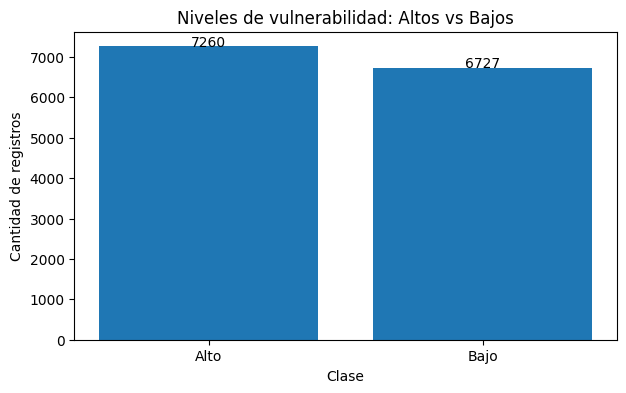

In [5]:
balanceo = (
    df['NIVEL_VULNERABILIDAD']
    .value_counts()
    .rename_axis('clase')
    .reset_index(name='cantidad')
)

balanceo['porcentaje'] = balanceo['cantidad'] / len(df) * 100
balanceo


plt.figure(figsize=(7, 4))
plt.bar(balanceo['clase'], balanceo['cantidad'])
plt.title('Niveles de vulnerabilidad: Altos vs Bajos')
plt.xlabel('Clase')
plt.ylabel('Cantidad de registros')

for i, valor in enumerate(balanceo['cantidad']):
    plt.text(i, valor + 3, str(valor), ha='center')

plt.show()

## **VARIABLES PREDICTORAS Y VARIABLE OBJETIVO**

In [6]:
X = df.drop(columns=['NIVEL_VULNERABILIDAD','PUNTAJE_VULNERABILIDAD','ETIQUETA_VULNERABILIDAD'])
y = df['ETIQUETA_VULNERABILIDAD']

X.head()

y.value_counts()

,count
ETIQUETA_VULNERABILIDAD,
2,7260
1,6727


## **PARTICION DE DATOS**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Tamaño X_train:', X_train.shape)
print('Tamaño X_test:', X_test.shape)
print('\nDistribución en entrenamiento:')
print(y_train.value_counts())
print('\nDistribución en prueba:')
print(y_test.value_counts())

Tamaño X_train: (11189, 12)
Tamaño X_test: (2798, 12)

Distribución en entrenamiento:
ETIQUETA_VULNERABILIDAD
2    5808
1    5381
Name: count, dtype: int64

Distribución en prueba:
ETIQUETA_VULNERABILIDAD
2    1452
1    1346
Name: count, dtype: int64


## **PREPROCESAMIENTO**

In [8]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer # Importar make_column_transformer

variables_ordinales = ['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA']

variables_numericas = ['EDAD']

variables_nominales = X_train.drop(columns=variables_ordinales + variables_numericas).columns.tolist()

# Crear el ColumnTransformer
preprocessor = make_column_transformer(
    (OrdinalEncoder(), variables_ordinales),
    (OneHotEncoder(handle_unknown='ignore'), variables_nominales),
    (StandardScaler(), variables_numericas),
    remainder='passthrough' # Mantener las columnas restantes si las hay sin transformar
)

# Resumen de preprocesamiento
resumen_preprocesamiento = pd.DataFrame({
    'columna': variables_ordinales + variables_nominales + variables_numericas,
    'tipo_de_variable': ['Ordinal'] * len(variables_ordinales) + ['Nominal'] * len(variables_nominales) + ['Numérica'] * len(variables_numericas),
    'transformacion': ['OrdinalEncoder'] * len(variables_ordinales) + ['OneHotEncoder'] * len(variables_nominales) + ['StandardScaler'] * len(variables_numericas)
})

print("Variables Ordinales:", variables_ordinales)
print("Variables Nominales:", variables_nominales)
print("Variables Numéricas:", variables_numericas)
display(resumen_preprocesamiento)


Variables Ordinales: ['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA']
Variables Nominales: ['GENERO', 'PERSONAS_EN_CONDICION_DE_DISCAPACIDAD', 'HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA', 'ADULTO_MAYOR', 'GRUPOS_ETNICOS_AFRO_INDIGENA', 'TIPO_DE_SEGURIDAD_EN_SALUD', 'CONDICION_OCUPACIONAL', 'BARRIO_O_VEREDA_DE_RESIDENCIA', 'ZONA_DE_RESIDENCIA', 'RANGO_EDAD']
Variables Numéricas: ['EDAD']


,columna,tipo_de_variable,transformacion
0,NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA,Ordinal,OrdinalEncoder
1,GENERO,Nominal,OneHotEncoder
2,PERSONAS_EN_CONDICION_DE_DISCAPACIDAD,Nominal,OneHotEncoder
3,HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA,Nominal,OneHotEncoder
4,ADULTO_MAYOR,Nominal,OneHotEncoder
5,GRUPOS_ETNICOS_AFRO_INDIGENA,Nominal,OneHotEncoder
6,TIPO_DE_SEGURIDAD_EN_SALUD,Nominal,OneHotEncoder
7,CONDICION_OCUPACIONAL,Nominal,OneHotEncoder
8,BARRIO_O_VEREDA_DE_RESIDENCIA,Nominal,OneHotEncoder
9,ZONA_DE_RESIDENCIA,Nominal,OneHotEncoder


In [9]:
# Definir categorias_ordinales a partir de los valores únicos en X_train
categorias_ordinales = [X_train['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA'].unique().tolist()]

preprocesamiento_unico = ColumnTransformer(
    transformers=[
        ('ordinales', OrdinalEncoder(
            categories=categorias_ordinales,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA']),

        ('nominales', OneHotEncoder(handle_unknown='ignore'), ['GENERO', 'PERSONAS_EN_CONDICION_DE_DISCAPACIDAD', 'HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA', 'ADULTO_MAYOR', 'GRUPOS_ETNICOS_AFRO_INDIGENA', 'TIPO_DE_SEGURIDAD_EN_SALUD', 'CONDICION_OCUPACIONAL', 'BARRIO_O_VEREDA_DE_RESIDENCIA', 'ZONA_DE_RESIDENCIA']),

        ('numericas', 'passthrough', variables_numericas)
    ]
)

preprocesamiento_unico

ColumnTransformer(transformers=[('ordinales',
                                 OrdinalEncoder(categories=[['3- BÁSICA '
                                                             'SECUNDARIA',
                                                             '8- TECNOLÓGICA',
                                                             '7- TÉCNICA '
                                                             'PROFESIONAL',
                                                             '10- '
                                                             'ESPECIALIZACIÓN',
                                                             '9- PROFESIONAL',
                                                             '14- NINGUNO',
                                                             '4- MEDIA '
                                                             'ACADÉMICA O '
                                                             'CLÁSICA',
                                                             '2- BÁSICA '
                                                             'PRIMARIA',
                                                             '13-UNIVERISITARIO',
                                                             '5- MEDIA TÉCNICA '
                                                             '(BACHILLERATO '
                                                             'TÉCNICO)',
                                                             '6- NORMALISTA',
                                                             '11- MAESTRÍA',
                                                             '12- DOCTORADO',
                                                             '1-...
                                 ['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA']),
                                ('nominales',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['GENERO',
                                  'PERSONAS_EN_CONDICION_DE_DISCAPACIDAD',
                                  'HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA',
                                  'ADULTO_MAYOR',
                                  'GRUPOS_ETNICOS_AFRO_INDIGENA',
                                  'TIPO_DE_SEGURIDAD_EN_SALUD',
                                  'CONDICION_OCUPACIONAL',
                                  'BARRIO_O_VEREDA_DE_RESIDENCIA',
                                  'ZONA_DE_RESIDENCIA']),
                                ('numericas', 'passthrough', ['EDAD'])])

## **DEFINICION DE MODELOS**

In [10]:
modelos = {
    'Regresión Logística': Pipeline(steps=[
        ('preprocesamiento', preprocesamiento_unico),
        ('modelo', LogisticRegression(
            C=0.05,
            max_iter=5000,
            random_state=42
        ))
    ]),

    'Árbol de Decisión': Pipeline(steps=[
        ('preprocesamiento', preprocesamiento_unico),
        ('modelo', DecisionTreeClassifier(
            max_depth=7,
            min_samples_leaf=2,
            random_state=42
        ))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocesamiento', preprocesamiento_unico),
        ('modelo', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=1
        ))
    ]),

    'SVC': Pipeline(steps=[
        ('preprocesamiento', preprocesamiento_unico),
        ('modelo', SVC(
            kernel='rbf',
            C=10,
            gamma=0.001,
            probability=True,
            random_state=42
        ))
    ])
}

In [11]:
resultados = []
predicciones = {}
matrices_confusion = {}

for nombre, pipeline in modelos.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=[1, 2])

    acierto_etiqueta_1 = cm[0, 0] / cm[0].sum()
    acierto_etiqueta_2 = cm[1, 1] / cm[1].sum()

    resultados.append({
        'modelo': nombre,
        'accuracy': acc,
        'acierto_etiqueta_1_vulnerabilidad_baja': acierto_etiqueta_1,
        'acierto_etiqueta_2_vulnerabilidad_alta': acierto_etiqueta_2,
        'correctos_vulnerabilidad_baja': cm[0, 0],
        'bajos_clasificados_como_altos': cm[0, 1],
        'altos_clasificados_como_bajos': cm[1, 0],
        'correctos_vulnerabilidad_alta': cm[1, 1]
    })

    predicciones[nombre] = y_pred
    matrices_confusion[nombre] = cm

resultados_df = pd.DataFrame(resultados).sort_values('accuracy', ascending=False)

resultados_porcentaje = resultados_df.copy()
columnas_porcentaje = [
    'accuracy',
    'acierto_etiqueta_1_vulnerabilidad_baja',
    'acierto_etiqueta_2_vulnerabilidad_alta'
]

resultados_porcentaje[columnas_porcentaje] = resultados_porcentaje[columnas_porcentaje] * 100
resultados_porcentaje[columnas_porcentaje] = resultados_porcentaje[columnas_porcentaje].round(2)

resultados_porcentaje

,modelo,accuracy,acierto_etiqueta_1_vulnerabilidad_baja,acierto_etiqueta_2_vulnerabilidad_alta,correctos_vulnerabilidad_baja,bajos_clasificados_como_altos,altos_clasificados_como_bajos,correctos_vulnerabilidad_alta
2,Random Forest,98.9600,99.3300,98.6200,1337,9,20,1432
1,Árbol de Decisión,97.4600,99.7000,95.3900,1342,4,67,1385
3,SVC,97.2100,98.5900,95.9400,1327,19,59,1393
0,Regresión Logística,97.0700,98.2200,96.0100,1322,24,58,1394


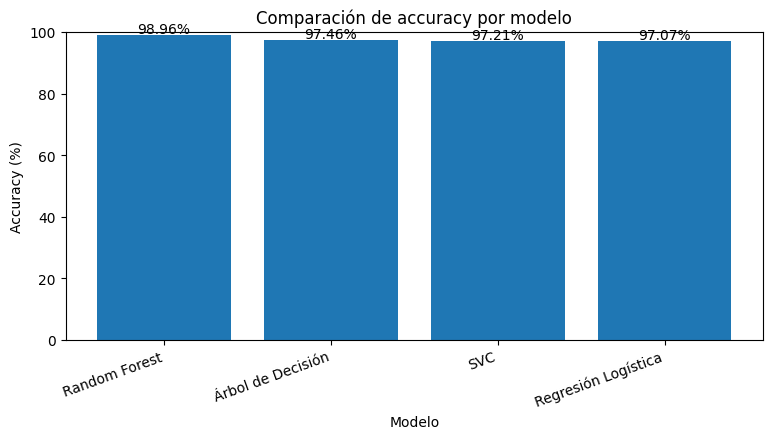

In [12]:
plt.figure(figsize=(9, 4))
plt.bar(resultados_porcentaje['modelo'], resultados_porcentaje['accuracy'])
plt.title('Comparación de accuracy por modelo')
plt.xlabel('Modelo')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=20, ha='right')

for i, valor in enumerate(resultados_porcentaje['accuracy']):
    plt.text(i, valor + 0.5, f'{valor:.2f}%', ha='center')

plt.ylim(0, 100)
plt.show()

### **MATRIZ DE CONFUSION**

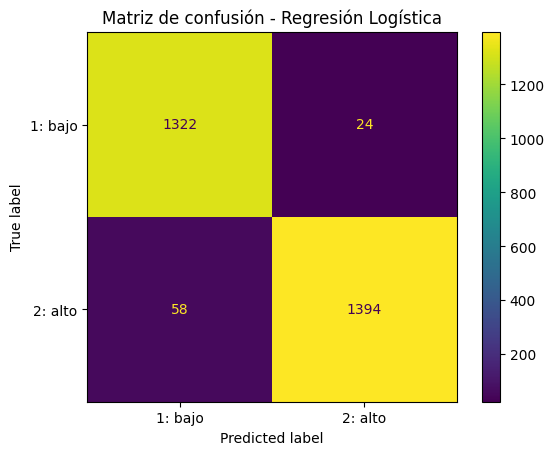

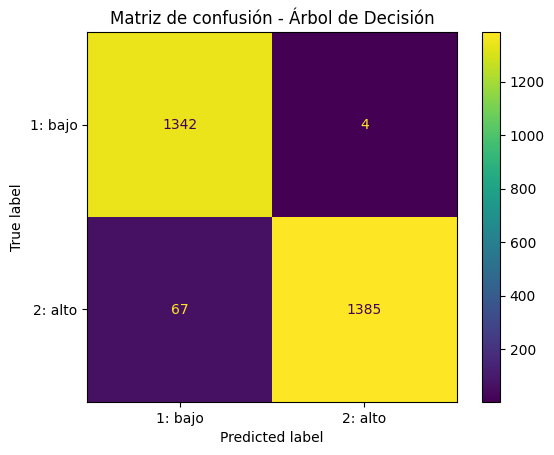

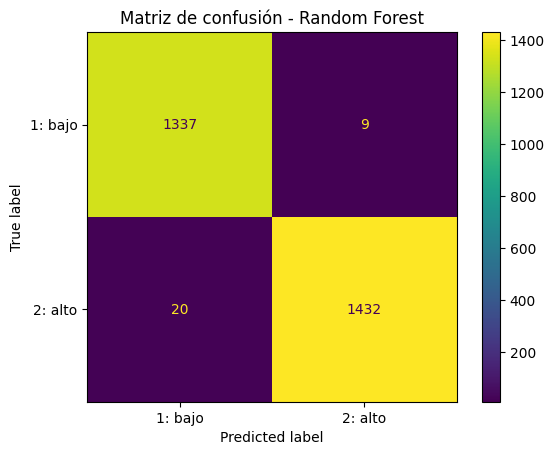

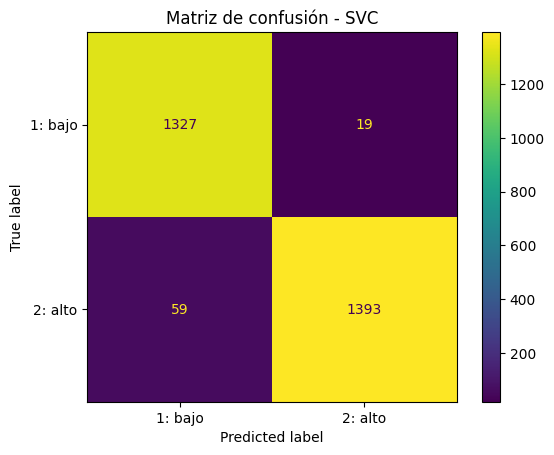

In [13]:
for nombre, cm in matrices_confusion.items():
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['1: bajo', '2: alto']
    )

    disp.plot(values_format='d')
    plt.title(f'Matriz de confusión - {nombre}')
    plt.show()

## **GRUPOS REALES VS GRUPOS PREDICHOS**


Modelo: Regresión Logística


,Real,Predicho
1: VULNERABILIDAD_BAJA,1346,1380
2: VULNERABILIDAD_ALTA,1452,1418


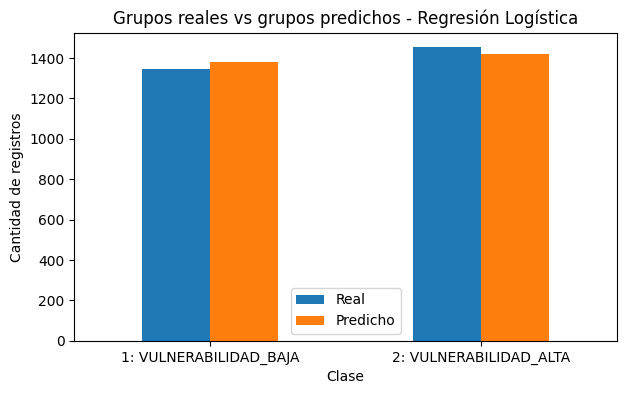


Modelo: Árbol de Decisión


,Real,Predicho
1: VULNERABILIDAD_BAJA,1346,1409
2: VULNERABILIDAD_ALTA,1452,1389


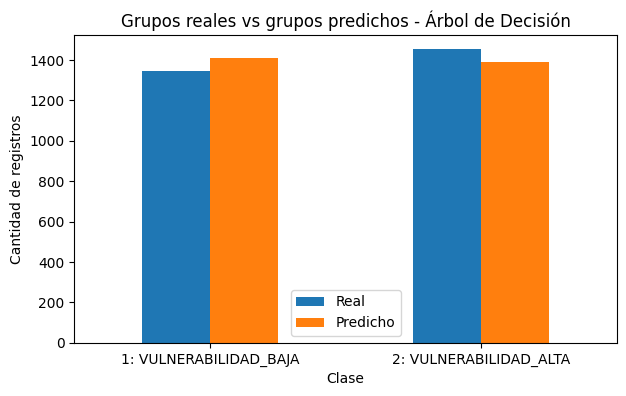


Modelo: Random Forest


,Real,Predicho
1: VULNERABILIDAD_BAJA,1346,1357
2: VULNERABILIDAD_ALTA,1452,1441


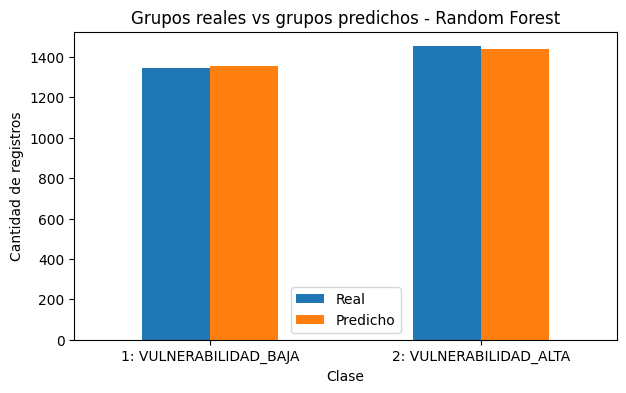


Modelo: SVC


,Real,Predicho
1: VULNERABILIDAD_BAJA,1346,1386
2: VULNERABILIDAD_ALTA,1452,1412


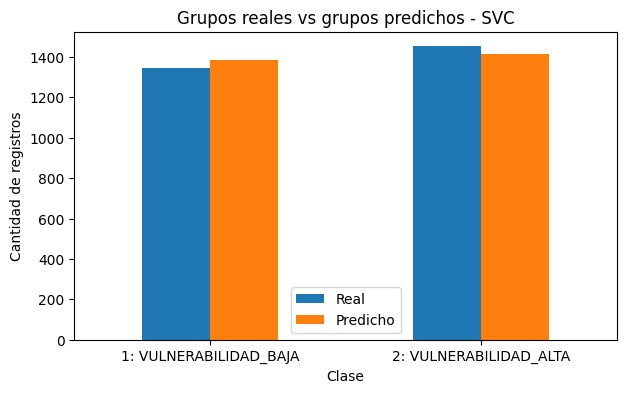

In [14]:
etiquetas = [1, 2]
nombres_etiquetas = {
    1: '1: VULNERABILIDAD_BAJA',
    2: '2: VULNERABILIDAD_ALTA'
}

conteo_real = pd.Series(y_test).value_counts().reindex(etiquetas, fill_value=0)
conteo_real.index = [nombres_etiquetas[i] for i in etiquetas]

for nombre, y_pred in predicciones.items():
    conteo_predicho = pd.Series(y_pred).value_counts().reindex(etiquetas, fill_value=0)
    conteo_predicho.index = [nombres_etiquetas[i] for i in etiquetas]

    comparacion = pd.DataFrame({
        'Real': conteo_real,
        'Predicho': conteo_predicho
    })

    print(f'\nModelo: {nombre}')
    display(comparacion)

    comparacion.plot(kind='bar', figsize=(7, 4))
    plt.title(f'Grupos reales vs grupos predichos - {nombre}')
    plt.xlabel('Clase')
    plt.ylabel('Cantidad de registros')
    plt.xticks(rotation=0)
    plt.show()

## **REPORTE**

In [15]:
for nombre, y_pred in predicciones.items():
    print('=' * 70)
    print(nombre)
    print(classification_report(
        y_test,
        y_pred,
        labels=[1, 2],
        target_names=['1: vulnerabilidad_baja', '2: vulnerabilidad_alta']
    ))

Regresión Logística
                        precision    recall  f1-score   support

1: vulnerabilidad_baja       0.96      0.98      0.97      1346
2: vulnerabilidad_alta       0.98      0.96      0.97      1452

              accuracy                           0.97      2798
             macro avg       0.97      0.97      0.97      2798
          weighted avg       0.97      0.97      0.97      2798

Árbol de Decisión
                        precision    recall  f1-score   support

1: vulnerabilidad_baja       0.95      1.00      0.97      1346
2: vulnerabilidad_alta       1.00      0.95      0.98      1452

              accuracy                           0.97      2798
             macro avg       0.97      0.98      0.97      2798
          weighted avg       0.98      0.97      0.97      2798

Random Forest
                        precision    recall  f1-score   support

1: vulnerabilidad_baja       0.99      0.99      0.99      1346
2: vulnerabilidad_alta       0.99      0.99  

## **SELECCION DEL MODELO**

In [16]:
mejor_nombre = resultados_df.iloc[0]['modelo']
mejor_accuracy = resultados_df.iloc[0]['accuracy']
mejor_modelo = modelos[mejor_nombre]

print(f'Mejor modelo: {mejor_nombre}')
print(f'Accuracy: {mejor_accuracy * 100:.2f}%')

Mejor modelo: Random Forest
Accuracy: 98.96%


In [17]:
mediana_vulnerabilidad = 2

paquete_modelo = {
    'modelo': mejor_modelo,
    'mediana_vulnerabilidad': mediana_vulnerabilidad,
    'columnas_entrada': X.columns.tolist(),
    'clases': {
        1: 'VULNERABILIDAD_BAJA',
        2: 'VULNERABILIDAD_ALTA'
    },
    'criterio': '1 = PUNTAJE_VULNERABILIDAD <= mediana; 2 = PUNTAJE_VULNERABILIDAD > mediana'
}

joblib.dump(paquete_modelo, '/content/drive/MyDrive/BootCamp_IA_2026/Pruebas/modeloClasificacion_final.pkl')

print('Modelo guardado como: modeloClasificacion.pkl')

Modelo guardado como: modeloClasificacion.pkl


In [18]:
resultados_df.to_csv('metricas_modelos_clasificacion_vulnerabilidad.csv', index=False)
print('Métricas guardadas como: metricas_modelos_clasificacion_vulnerabilidad.csv')

Métricas guardadas como: metricas_modelos_clasificacion_vulnerabilidad.csv
